<a href="https://colab.research.google.com/github/jfbadarom/Fisica-com-Python/blob/main/Tarefa_1_Jo%C3%A3o_Felipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa Avaliativa 1

TA1

**Para ir para o GITHUB**

Coloque o seguinte cabeçalho:

> Tarefa 1:

*   Disciplina: Física com Python 1 (2026.2) — CBPF
*   Autor: João Felipe Pinheiro Badaró Moreira
*   Obs: Código desenvolvido para fins de avaliação acadêmica. Disponibilizado publicamente sob a Licença MIT para consulta educacional.



##Q1

Aplique o **ridge-plot** (gráfico de cordilheira) para visualizar algum resultado da sua grande área de pesquisa.

**ridge-plot**:
*  https://seaborn.pydata.org/examples/kde_ridgeplot
*  https://python-graph-gallery.com/ridgeline-graph-seaborn/


Um exemplo de aplicação de ridge plot é a evolução de um sistema quântico com distribuição espacial  como a função de onda que descreve a posição de uma particula com o tempo $Ψ(x,t)$ para uma partícula de massa $m$ em um poço de potencial unidimensional infinito de largura $L$, $V(x)=0$ para $0< x<L$ e $V(x)→∞$ para $x\leq 0, x\geq L$. Selecionamos recortes temporais especificos(projeções) que possamos ver a sua evolução

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
h=1# Vamos considerar a hcortado como 1
def wave_function(x, t, L, m, n):
  return((2/L)**(1/2)*np.sin(n*np.pi*x/L)*np.exp(-(n**2*np.pi**2*h**2*t)/(2*m*L**2)))# Definição da função de onda da particula localizada no poço


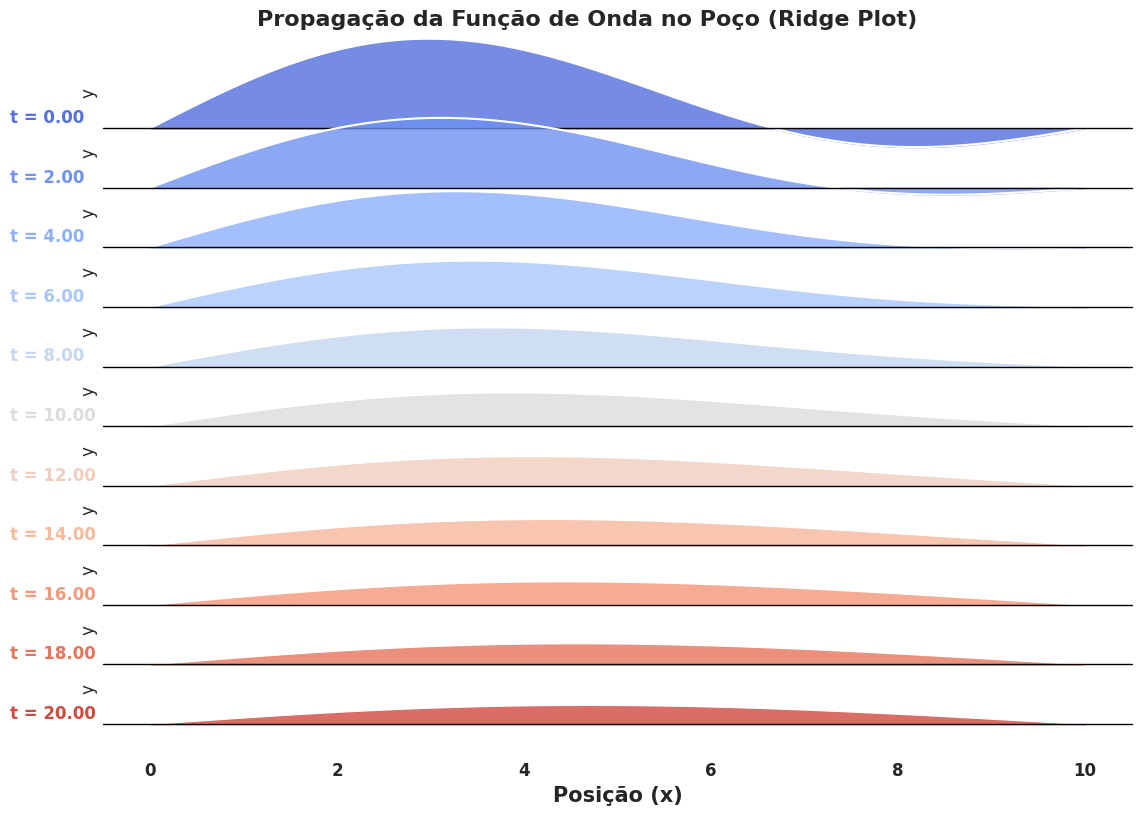

In [84]:

L = 10 # Tamanho do poço
m = 1  # Massa
n1 = 1  # Autoestado
n2 = 2 # Autoestado

tvec = np.linspace(0, 20, 11)
xvec = np.linspace(0, L, 101)

Wave = []

for t in tvec:
    # Calcula a onda para o instante t
    wave_in_time_t = wave_function(xvec, t, L, m, n)+wave_function(xvec, t, L, m, n+1) #Soma dois autoestados
    for x, y in zip(xvec, wave_in_time_t):
        Wave.append({'x': x, 'y': y, 't_label': f't = {t:.2f}'})
df = pd.DataFrame(Wave)


pal = sns.color_palette(palette='coolwarm', n_colors=len(tvec))


g = sns.FacetGrid(df, row='t_label', hue='t_label', aspect=15, height=0.75, palette=pal)

def plot_ridge(x, y, **kwargs):
    color = kwargs.get('color', 'blue')
    ax = plt.gca()


    ax.fill_between(x, y, color=color, alpha=0.8)
    ax.plot(x, y, color='white', lw=1.5, clip_on=False)
    ax.axhline(y=0, color='black', lw=1, clip_on=False)

g.map(plot_ridge, 'x', 'y')

g.fig.subplots_adjust(hspace=-0.5)

g.set_titles("")
g.set(yticks=[])
g.despine(bottom=True, left=True)

t_labels = df['t_label'].unique()
for i, ax in enumerate(g.axes.flat):
    ax.text(-1.5, 0.05, t_labels[i],
            fontweight='bold', fontsize=12, color=pal[i])

plt.setp(ax.get_xticklabels(), fontsize=12, fontweight='bold')
plt.xlabel('Posição (x)', fontweight='bold', fontsize=15)
g.fig.suptitle('Propagação da Função de Onda no Poço (Ridge Plot)',
               ha='center', fontsize=16, fontweight='bold')

plt.show()

##Q2

Aplique o **ternary-plot** (gráfico ternário) para visualizar algum resultado da sua grande área de pesquisa.

**ternary-plot**:
*  https://plotly.com/python/ternary-plots/
*  https://www.geeksforgeeks.org/python/ternary-plots-in-plotly/


Um gráfico ternário é pode ser muito útil para representar um estado quântico de três níveis pois a base é formada por 3 vetores e qualquer vetor que pertença a esse espaço(estado puro) pode ser descrito a partir dessa mistura.

Estado 1 $→ |\psi\rangle=\sqrt{\frac{2}{5}}|0\rangle+ \sqrt{\frac{1}{5}}|1\rangle+ \sqrt{\frac{2}{5}}|2\rangle$

Estado 2 $→ |\psi\rangle=\sqrt{\frac{2}{5}}|0\rangle+ \sqrt{\frac{2}{5}}|1\rangle+ \sqrt{\frac{1}{5}}|2\rangle$

Estado 3 $→ |\psi\rangle=\sqrt{\frac{1}{2}}|0\rangle+ \sqrt{\frac{1}{2}}|1\rangle$

Estado 4 $→ |\psi\rangle=\sqrt{\frac{1}{3}}|0\rangle+ \sqrt{\frac{1}{3}}|1\rangle+ \sqrt{\frac{1}{3}}|2\rangle$

In [85]:

import plotly.express as px
import pandas as pd

dados = [
    {r'$|0\rangle$': 0.4, r'$|1\rangle$': 0.2, r'$|2\rangle$': 0.4, "Estado": "1"},
    {r'$|0\rangle$': 0.4, r'$|1\rangle$': 0.4, r'$|2\rangle$': 0.2, "Estado": "2"},
    {r'$|0\rangle$': 0.5, r'$|1\rangle$': 0.5, r'$|2\rangle$': 0.0, "Estado": "3"},
    {r'$|0\rangle$': 0.33, r'$|1\rangle$': 0.33, r'$|2\rangle$': 0.33, "Estado": "4" }
]
df = pd.DataFrame(dados)

fig = px.scatter_ternary(df, color="Estado", a=r'$|0\rangle$', b=r'$|1\rangle$', c=r'$|2\rangle$')

fig.update_layout(
    font=dict(size=16)
)

fig.show()

##Q3

Faça um gráfico com **inset** para visualizar algum resultado da sua grande área de pesquisa.

Exemplo:
https://scipython.com/blog/inset-plots-in-matplotlib/

In [97]:
!pip install qiskit#Biblioteca externa pra trazer um resultado que obtive recentemente recriando o resultado de um artigo
!pip install qiskit_aer

In [98]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, partial_trace, concurrence
from qiskit.circuit.library import PauliEvolutionGate
import matplotlib.pyplot as plt
from qiskit.quantum_info import partial_trace, negativity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit import transpile

<Figure size 1000x600 with 0 Axes>

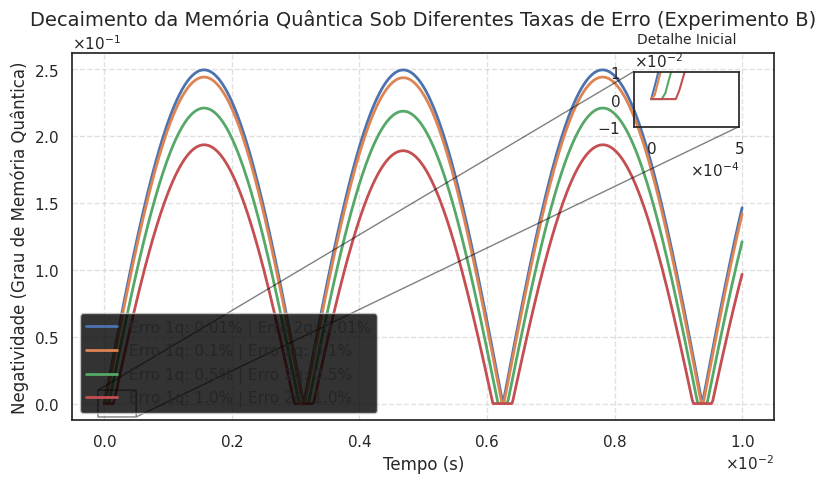

In [108]:

# ==========================================
# 1. Parâmetros e Construção do Hamiltoniano
# ==========================================
# Usando os parâmetros propostos para o seu experimento de RMN
J_eff = 160 # Acoplamento efetivo em Hz
c = np.pi * J_eff / 2
dt1 = 0.01 # 0.1 ms de tempo de evolução
B = np.pi * 500

H_eff = SparsePauliOp.from_list([
    ("XX", c),
    ("YY", c),
    ("ZZ", c),
    ("ZI", B),
    ("IZ", B),
])

S, E1, E2 = 0, 1, 2
tvec = np.linspace(0, dt1, 500)  # Reduzi para 50 pontos para a simulação rodar mais rápido

# ==========================================
# 2. Definição das Taxas de Erro a serem testadas
# ==========================================
# Vamos testar 4 cenários:
# 0% (Ideal), 0.1% (Baixo), 1% (Médio) e 5% (Alto) de erro em portas de 1 qubit.
taxas_de_erro_1_qubit = [0.0001, 0.001, 0.005, 0.01]

plt.figure(figsize=(10, 6))#plots
fig, ax = plt.subplots(figsize=(8, 5))
ax_inset = ax.inset_axes([0.80, 0.80, 0.15, 0.15])#inset
# ==========================================
# 3. LAÇO EXTERNO: Percorre os modelos de ruído
# ==========================================
for erro_1q in taxas_de_erro_1_qubit:


    erro_2q = min(1.0, erro_1q )

    # Monta o modelo de ruído para a iteração atual
    noise_model = NoiseModel()
    if erro_1q > 0.0:  # Se não for o caso ideal, adicionamos o ruído
        error_1 = depolarizing_error(erro_1q, 1)
        error_2 = depolarizing_error(erro_2q, 2)
        noise_model.add_all_qubit_quantum_error(error_1, ['rz', 'sx', 'x'])
        noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

    simulador = AerSimulator(noise_model=noise_model, method='density_matrix')
    grau_emaranhamento = []

    # ==========================================
    # 4. LAÇO INTERNO: Evolução no tempo (como antes)
    # ==========================================
    for t in tvec:
        qc = QuantumCircuit(3)
        qc.h(S)

        if t > 0: # Evita tentar evoluir um tempo nulo
            qc.append(PauliEvolutionGate(H_eff, time=t), [S, E1])

        qc_transpilado = transpile(qc, basis_gates=['cx', 'rz', 'sx', 'x'])
        qc_transpilado.save_density_matrix()

        # Roda a simulação com a taxa de erro atual
        resultado = simulador.run(qc_transpilado).result()
        estado_ruidoso = resultado.data()['density_matrix']

        rho_S_E1 = partial_trace(estado_ruidoso, [E2])

        # Lembra do parâmetro qargs=[0] para evitar o TypeError!
        grau_emaranhamento.append(negativity(rho_S_E1, qargs=[0]))

    # Plota a linha correspondente a esta taxa de erro
    ax.plot(tvec, grau_emaranhamento, label=f'Erro 1q: {erro_1q*100}% | Erro 2q: {erro_2q*100}%', linewidth=2)
    ax_inset.plot(tvec, grau_emaranhamento)


plt.xlabel("Tempo (s)", fontsize=12)
plt.ylabel("Negatividade (Grau de Memória Quântica)", fontsize=12)
plt.title("Decaimento da Memória Quântica Sob Diferentes Taxas de Erro (Experimento B)", fontsize=14)
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
ax_inset.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
ax_inset.set_ylim(-0.01, 0.01)
ax_inset.set_xlim(-0.0001, 0.0005)
ax.indicate_inset_zoom(ax_inset, edgecolor="black")
ax_inset.plot( color='red')
ax_inset.set_title("Detalhe Inicial", fontsize=10)
plt.show()

##Q4

Faça um gráfico com **animação** para visualizar dinamicamente algum resultado da sua grande área de pesquisa.


Exemplos: https://python-graph-gallery.com/animation/

Vou levantar novamente o exemplo do gráfico do ridge plot e usar o que construimos anteriormente.

In [113]:
tvec = np.linspace(0, 20, 101)
Wave=[]
for t in tvec:
    # Calcula a onda para o instante t
    wave_in_time_t = wave_function(xvec, t, L, m, n)+wave_function(xvec, t, L, m, n+1) #Soma dois autoestados
    for x, y in zip(xvec, wave_in_time_t):
        Wave.append({'x': x, 'y': y, 't_label': f't = {t:.2f}'})
df = pd.DataFrame(Wave)

In [114]:
import plotly.express as px

# Importante: defina os limites do eixo Y (range_y) para a amplitude máxima da sua onda.
# Se não fixar o range, o gráfico vai mudar de escala a cada frame e arruinar o efeito.
amplitude_max = df['y'].max() * 1.1
amplitude_min = df['y'].min() * 1.1

fig = px.line(
    df,
    x='x',
    y='y',
    animation_frame='t_label', # É aqui que a mágica acontece
    range_y=[amplitude_min, amplitude_max],
    title='Evolução Temporal do Estado Não-Estacionário'
)

# Opcional: melhorando o visual
fig.update_layout(xaxis_title="Posição (x)", yaxis_title=r"$\Psi(x,t)$")

fig.show()

##Q5
Acesse a documentação do [scipy-stats](https://docs.scipy.org/doc/scipy/reference/stats.html) em seguida:

* Escolha 6 distribuições de [variáveis continuas](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions)  que permitam discutir graficamente a **variância**, **skewness** e **kurtosis** de modo representativo. **Organize os paineis em grid 2x3 usando  [plt.subplots(nrows=2, ncols=3, figsize=(15, 8))](https://www.geeksforgeeks.org/data-visualization/how-to-generate-subplots-with-pythons-matplotlib/)**. Coloque no *título* de cada painel o valor da variância, skewness e kurtosis.


Escolhi as distribuições $\alpha$, $\beta$, $\gamma$, Laplace, Maxwell e $\chi$

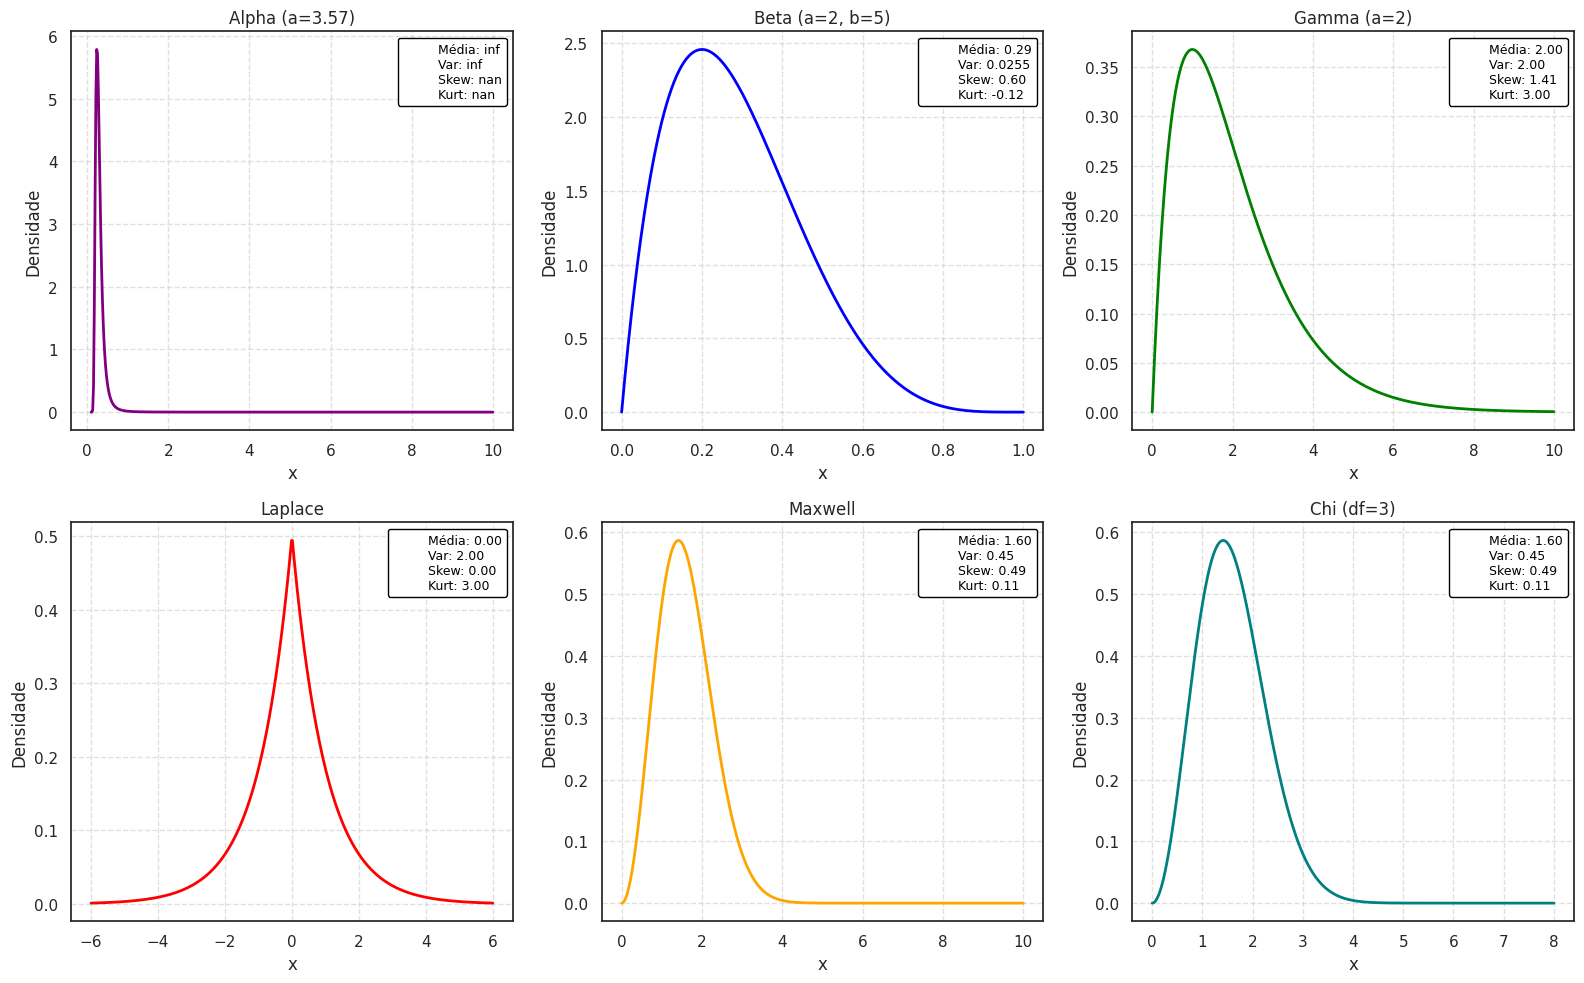

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import alpha, beta, gamma, laplace, maxwell, chi

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# 1. Distribuição Alpha (a=1)

a_alpha = 3.57
x_alpha = np.linspace(0.1, 10, 500)
m, v, s, k = alpha.stats(a_alpha, moments='mvsk')
stats_alpha = f"Média: {m:.2f}\nVar: {v:.2f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[0, 0].plot(x_alpha, alpha.pdf(x_alpha, a_alpha), color='purple', lw=2)
axes[0, 0].plot([], [], ' ', label=stats_alpha)
axes[0, 0].set_title(f'Alpha (a={a_alpha})')

# 2. Distribuição Beta (a=2, b=5)

a_beta, b_beta = 2, 5
x_beta = np.linspace(0, 1, 500)
m, v, s, k = beta.stats(a_beta, b_beta, moments='mvsk')
stats_beta = f"Média: {m:.2f}\nVar: {v:.4f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[0, 1].plot(x_beta, beta.pdf(x_beta, a_beta, b_beta), color='blue', lw=2)
axes[0, 1].plot([], [], ' ', label=stats_beta)
axes[0, 1].set_title(f'Beta (a={a_beta}, b={b_beta})')

# 3. Distribuição Gamma (a=2)

a_gamma = 2
x_gamma = np.linspace(0, 10, 500)
m, v, s, k = gamma.stats(a_gamma, moments='mvsk')
stats_gamma = f"Média: {m:.2f}\nVar: {v:.2f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[0, 2].plot(x_gamma, gamma.pdf(x_gamma, a_gamma), color='green', lw=2)
axes[0, 2].plot([], [], ' ', label=stats_gamma)
axes[0, 2].set_title(f'Gamma (a={a_gamma})')

# 4. Distribuição Laplace (padrão)

x_laplace = np.linspace(-6, 6, 500)
m, v, s, k = laplace.stats(moments='mvsk')
stats_laplace = f"Média: {m:.2f}\nVar: {v:.2f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[1, 0].plot(x_laplace, laplace.pdf(x_laplace), color='red', lw=2)
axes[1, 0].plot([], [], ' ', label=stats_laplace)
axes[1, 0].set_title('Laplace')

# 5. Distribuição Maxwell (padrão)

x_maxwell = np.linspace(0, 10, 500)
m, v, s, k = maxwell.stats(moments='mvsk')
stats_maxwell = f"Média: {m:.2f}\nVar: {v:.2f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[1, 1].plot(x_maxwell, maxwell.pdf(x_maxwell), color='orange', lw=2)
axes[1, 1].plot([], [], ' ', label=stats_maxwell)
axes[1, 1].set_title('Maxwell')

# 6. Distribuição Chi (df=3)

df_chi = 3
x_chi = np.linspace(0, 8, 500)
m, v, s, k = chi.stats(df_chi, moments='mvsk')
stats_chi = f"Média: {m:.2f}\nVar: {v:.2f}\nSkew: {s:.2f}\nKurt: {k:.2f}"

axes[1, 2].plot(x_chi, chi.pdf(x_chi, df_chi), color='teal', lw=2)
axes[1, 2].plot([], [], ' ', label=stats_chi)
axes[1, 2].set_title(f'Chi (df={df_chi})')
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel('Densidade')
    ax.set_xlabel('x')
    ax.legend(loc='upper right', fontsize=9, edgecolor='black', facecolor='white', framealpha=1, labelcolor='black')

plt.tight_layout()
plt.show()